# Barotropic instability of a zonal jet in a channel

A single-layer shallow-water experiment (`OSSWEM`) on a $\beta$-plane. The domain is a
zonal channel: **periodic in $x$**, with **solid walls north and south** (imposed as dry
rows, $D=0$). A balanced eastward jet is held against instability by a localized sponge,
while the interior of the channel is free to evolve.

## The problem

A zonal jet $\bar{u}(y)$ that is sharp enough develops a sign change in the meridional
gradient of background potential vorticity. By the **Rayleigh–Kuo / Charney–Stern**
criterion this is a *necessary* condition for barotropic instability. The jet here
satisfies it, so a small perturbation grows into meanders and eddies that fluxes momentum
and stir PV — the classic route by which a jet sheds eddies. The localized sponge keeps
re-supplying the unstable jet, so the channel reaches a statistically steady turbulent
state rather than mixing the jet away.

The instability is *barotropic* (drawing on the horizontal shear of the mean flow); with a
single layer there is no baroclinic (vertical-shear) energy source.

## Configuration

| Quantity | Value | Notes |
|---|---|---|
| Domain | $900 \times 600$ km | 50% longer in $x$ than $y$ |
| Resolution | $\Delta x = \Delta y = 10$ km | at the default `nj = 60` ($n_i = 90$) |
| Reduced gravity $g'$ | $0.08$ m $\text{s}^{-2}$ | gravity-wave speed $c_g=\sqrt{g'H}\approx 8$ m $s^{-1}$ |
| Layer thickness $H$ | $800$ m | |
| Coriolis $f_0$, $\beta$ | $10^{-4} \text{s}^{-1}$, $3\times 10^{-11}$ $\text{m}^{-1} \text{s}^{-1}$ | deformation radius $R_d=c_g/f_0\approx 80$ km |
| Bottom drag $\epsilon$ | $2.5\times10^{-5}$ m $\text{s}^{-1}$ | |
| Lateral viscosity $\nu_h$ | $200$ $\text{m}^2$ $\text{s}^{-1}$ | |

- **Jet target:** eastward, peak $1$ m $\text{s}^{-1}$, spanning $y/L_y \in [0.4, 0.6]$ (half-width
  $\sim 60$ km, comparable to $R_d$). Its free surface is set in geostrophic balance,
  $f\,u = -g'\,\partial_y\eta$, and used as the initial state everywhere.
- **Sponge (forcing):** restores $u\to$ jet, $v\to 0$, $h\to$ balanced at rate
  $10^{-5}$ $\text{s}^{-1}$ over the westernmost $150$ km plus the outer $100$ km near each wall.
  The $\beta$ term arrests the largest meridional mode. The restoring is applied with a
  backward-Euler step (unconditionally stable). The rest of the domain is unforced.
- **Seed:** a small smooth Gaussian bump in $h$ perturbs the balanced state to trigger the
  instability.

The `nj`/`run_params` line in the next cell selects the resolution and run length; coarser
settings run fast and still capture the instability, finer ones resolve more eddies.

## Notebook outline

1. **Setup** — build the model, jet, sponge, and initial perturbation; plot the configuration.
2. **Instability criterion** — evaluate Rayleigh–Kuo and Charney–Stern on the initial jet.
3. **Run** — integrate forward, sampling snapshots.
4. **Snapshot** — final $\eta$, eddy field $\eta'$, absolute vorticity, and PV.
5. **Time series** — surface-height and velocity extrema, and kinetic energy vs. time.
6. **Animation** — evolution of potential vorticity.

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from OSSWEM import SSWEM

mesh: ni = 180  nj = 120
Grid: dx = 5000.0 [m]  dy = 5000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = 1041.6666666666667 [m]
Scales: Lx/Ld = 11.25
Res: Ld/dx = 16.0
Res: Ls/dx = 0.20833333333333334


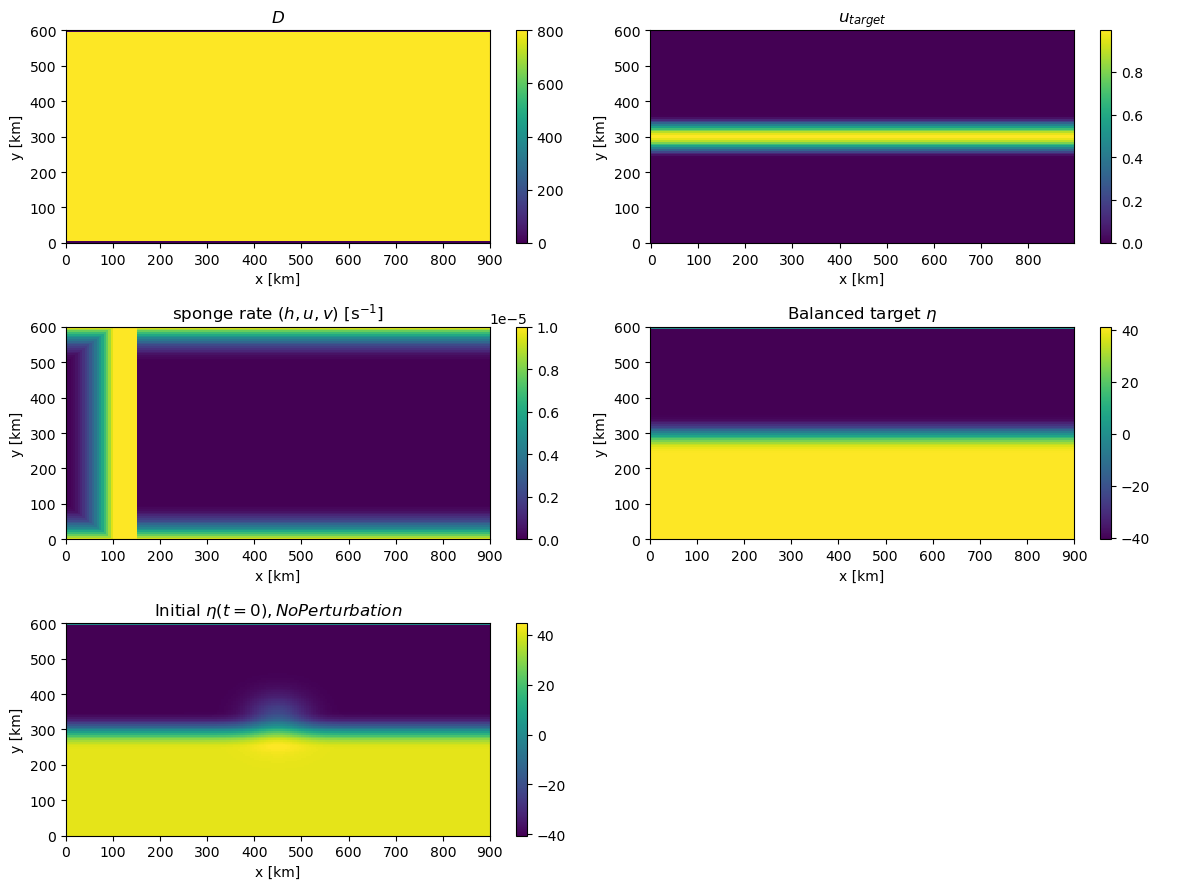

In [ ]:
# Barotropic instability in a channel: a balanced zonal jet maintained by a
# localized western sponge (beta-plane).

# nj, ru_params = [dt, steps/segment, segments]
# nj, run_params = 40, [200., 500, 25]  # Barely permitted eddies
# nj, run_params = 60, [200., 500, 25]  # Coarsest resolution with good instabilities
nj, run_params = 120, [50., 2000, 25]  # Finer resolution
# nj, run_params = 180, [5., 5000, 100]  # Finer resolution is very unstable

M = SSWEM(nj + nj//2,
          0.08,    # Gravity [m s-2]
          800.,    # Nominal layer thickness [m]
          900.e3,  # Domain width [m]  (50% longer in x than y)
          1.e-4,   # Coriolis [s-1]
          3.0e-11, # df/dy [m-1 s-1]  (beta-plane arrests the large-scale meridional mode)
          2.5e-5,  # Bottom drag rate [m s-1]
          2e2,     # Lateral viscosity [m2 s-1]
          nj=nj    # Rectangular channel
          )
M.D[0,:] = 0       # dry rows N/S -> zonal channel walls
M.D[-1,:] = 0

# Target zonal jet and its geostrophically balanced free surface (f u = -g d(eta)/dy)
M.set_u_target_jet(1.0)                            # u_target = jet(y)
uy  = M.u_target[0].mean(axis=1)                   # u(y)
f_h = M.fo + M.beta * M.yh1                        # f(y) at row centres
eta = -(1.0/M.g[0]) * np.cumsum(f_h * uy) * M.dy
eta -= eta.mean() # Why remove mean? 
hbal = np.maximum(M.D + eta[:, None], 0.0)         # balanced thickness

# Sponges restoring u->jet, v->0, h->balanced: a western sponge over the westernmost
# 150 km, plus N/S near-wall sponges over the outer 100 km.
# Local forcing only; the rest of the domain is free to evolve.
def ramp(x, x0, Lx): return np.clip((x - x0)/(Lx - x0), 0, 1)**2
def ramp2(x, x0, Lx): return np.clip(1.5*(x - x0)/(Lx - x0), 0, 1)**2
rate, Lw, yb = 1.0e-5, 150.e3, 100e3               # western sponge width Lw; near-wall band yb
# Western sponge: the eastern ramp shifted to [0, Lw] -- same W->E rise (0 at x=0 up to
# the max), then masked to 0 beyond Lw so it drops discontinuously to 0 at x=Lw.
M.u_relax  = rate * np.maximum( np.maximum( ramp2(M.xu, 0., Lw) * (M.xu < Lw), ramp(M.yu, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yu, M.Ly - yb, M.Ly) )
M.v_relax  = rate * np.maximum( np.maximum( ramp2(M.xv, 0., Lw) * (M.xv < Lw), ramp(M.yv, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yv, M.Ly - yb, M.Ly) )
M.h_relax  = rate * np.maximum( np.maximum( ramp2(M.xh, 0., Lw) * (M.xh < Lw), ramp(M.yh, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) )
M.h_target = hbal[None, :, :].copy()               # u_target/v_target already set (jet / 0)

# Balanced initial state everywhere + a small smooth perturbation to seed eddies
M.u[0] = M.u_target[0].copy()
M.h[0] = hbal.copy()
M.perturb_h(20., 0.05 * M.Lx, 0.5 * M.Lx, 0.55 * M.Ly)

# Setup diagnostics
fig, ax = plt.subplots(3, 2, figsize=(12, 9))
cs = ax[0,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.D ); fig.colorbar(cs, ax=ax[0,0]); ax[0,0].set_title(r'$D$');
cs = ax[0,1].pcolormesh( M.xq1/1e3, M.yh1/1e3, M.u_target[0] ); fig.colorbar(cs, ax=ax[0,1]); ax[0,1].set_title(r'$u_{target}$');
cs = ax[1,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.h_relax[0] ); fig.colorbar(cs, ax=ax[1,0]); ax[1,0].set_title(r'sponge rate ($h,u,v$) [$\text{s}^{-1}$]');
cs = ax[1,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, hbal - M.D ); fig.colorbar(cs, ax=ax[1,1]); ax[1,1].set_title(r'Balanced target $\eta$');
cs = ax[2,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=ax[2,0]); ax[2,0].set_title(r'Initial $\eta(t=0), No Perturbation$');
ax[2,1].axis('off')                                # no sixth panel
for a in (ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0]):
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout();

Rayleigh-Kuo (beta - U_yy) changes sign in interior: True


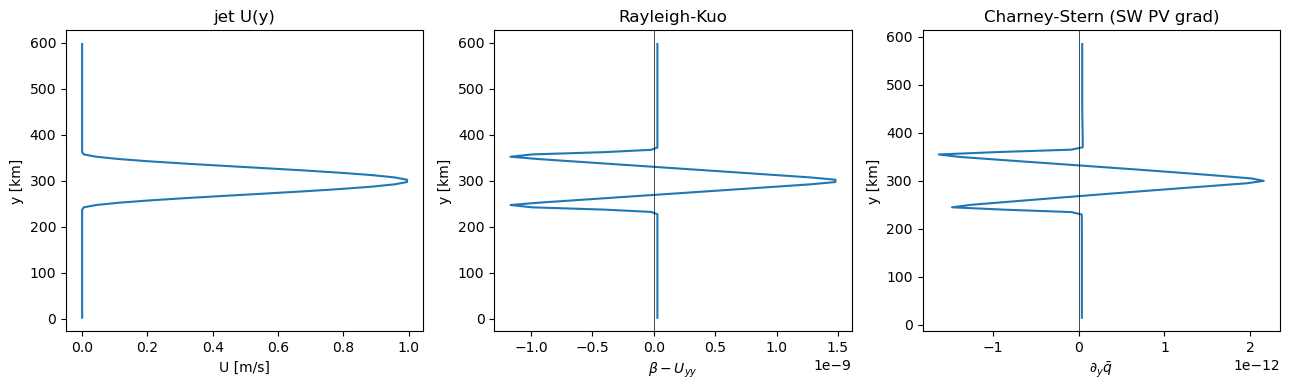

In [24]:
# Barotropic-instability criterion (Rayleigh-Kuo / Charney-Stern): a NECESSARY
# condition for instability is that the background potential-vorticity gradient
# changes sign in the interior. Evaluated on the initial balanced jet.
# See https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Kuo_criterion

U   = M.u[0].mean(axis=1)                          # U(y)
Uyy = np.gradient(np.gradient(U, M.yh1), M.yh1)
RK  = M.beta - Uyy                                 # Rayleigh-Kuo (non-divergent barotropic)
dqdy = np.gradient(M.q(k=0).mean(axis=1), M.yq1)   # Charney-Stern: d/dy of zonal-mean SW PV
dqdy[:3] = np.nan                                  # mask near-wall rows where h->0 makes
dqdy[-2:] = np.nan                                 # q=(f+zeta)/h spike and swamp the interior

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(U, M.yh1/1e3);    ax[0].set_xlabel('U [m/s]'); ax[0].set_ylabel('y [km]'); ax[0].set_title('jet U(y)')
ax[1].plot(RK, M.yh1/1e3);   ax[1].axvline(0, color='k', lw=0.5); ax[1].set_xlabel(r'$\beta - U_{yy}$'); ax[1].set_ylabel('y [km]'); ax[1].set_title('Rayleigh-Kuo')
ax[2].plot(dqdy, M.yq1/1e3); ax[2].axvline(0, color='k', lw=0.5); ax[2].set_xlabel(r'$\partial_y \bar{q}$'); ax[2].set_ylabel('y [km]'); ax[2].set_title('Charney-Stern (SW PV grad)')
fig.tight_layout()
# With the near-wall spike masked, the interior sign change in the SW PV gradient is
# visible in the Charney-Stern panel; the Rayleigh-Kuo panel is the cleaner read.

jj = (M.yh1/M.Ly > 0.12) & (M.yh1/M.Ly < 0.88)     # interior (skip dry walls)
print('Rayleigh-Kuo (beta - U_yy) changes sign in interior:', bool((RK[jj].min() < 0) and (RK[jj].max() > 0)))

In [25]:
# Run the model
# %time u,v,h,time = M.run(50., 2000, 25); # dt, steps/segment, segments
%time u,v,h,time = M.run(*run_params); # dt, steps/segment, segments

numba threads = 16
CFL: dt*f = 0.0058925
CFL: dt*cg/dx = 0.08
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 1.5625e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.0005
CFL*: dt*u_relax = 0.0005
CFL*: dt*v_relax = 0.0005
nsteps = 50000
Time: Trun * fo = 250.0
Time: Trun * ( cg / L ) = 22.22222222222222
Running...
...done
CPU times: total: 10min 54s
Wall time: 1min 12s


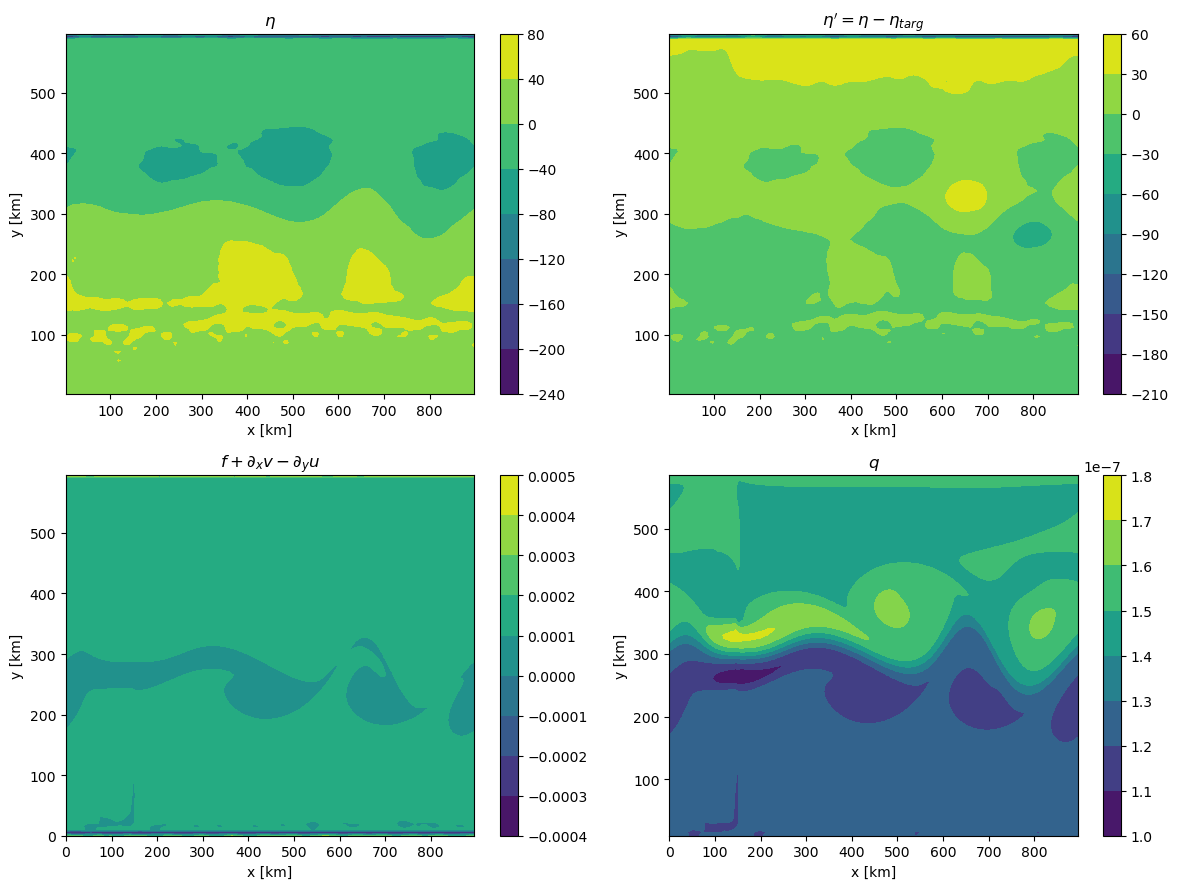

In [26]:
# Snapshot
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
cs = axs[0,0].contourf( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=axs[0,0]); axs[0,0].set_title(r"$\eta$");
cs = axs[0,1].contourf( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) - (M.h_target[0] - M.D) ); fig.colorbar(cs, ax=axs[0,1]); axs[0,1].set_title(r"$\eta' = \eta - \eta_{targ}$");
cs = axs[1,0].contourf( M.xq1/1e3, M.yq1/1e3, M.abs_omega(k=0) ); fig.colorbar(cs, ax=axs[1,0]); axs[1,0].set_title(r'$f + \partial_x v - \partial_y u$');
cs = axs[1,1].contourf( M.xq1/1e3, M.yq1[2:-2]/1e3, M.q(h=h[-1], u=u[-1], v=v[-1], k=0)[2:-2,:] ); fig.colorbar(cs, ax=axs[1,1]); axs[1,1].set_title(r'$q$');
for a in axs.ravel():
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout();

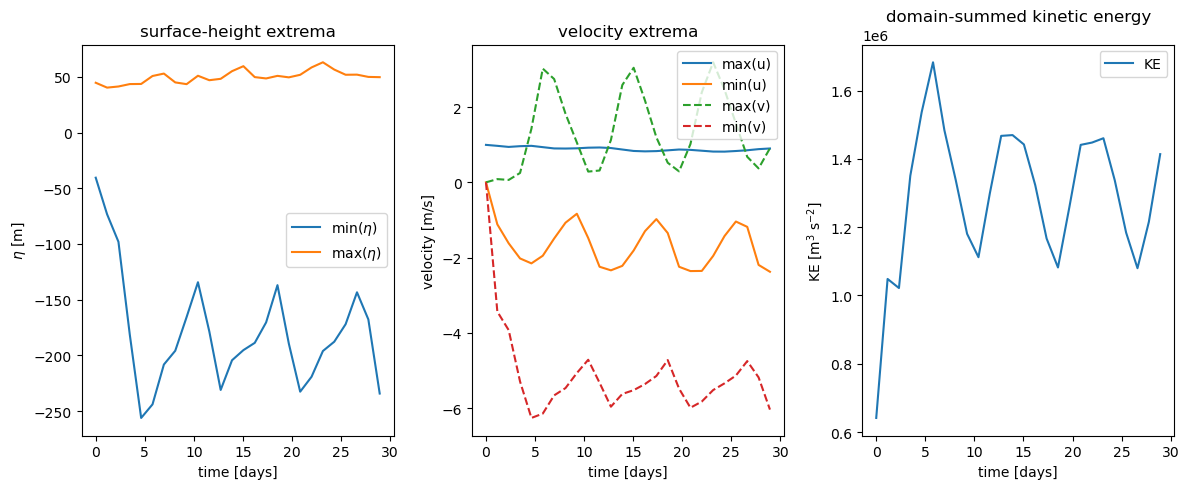

In [ ]:
# Plot time series
fig,ax = plt.subplots(1,3,figsize=(12,5))
ax[0].plot( time/86400, (h - M.D).min(axis=(1,2,3)), label=r'min($\eta$)' )
ax[0].plot( time/86400, (h - M.D).max(axis=(1,2,3)), label=r'max($\eta$)' )
ax[0].set_xlabel('time [days]'); ax[0].set_ylabel(r'$\eta$ [m]'); ax[0].set_title('surface-height extrema'); ax[0].legend();
ax[1].plot( time/86400, u.max(axis=(1,2,3)), label='max(u)' )
ax[1].plot( time/86400, u.min(axis=(1,2,3)), label='min(u)' )
ax[1].plot( time/86400, v.max(axis=(1,2,3)), '--', label='max(v)' )
ax[1].plot( time/86400, v.min(axis=(1,2,3)), '--', label='min(v)' )
ax[1].set_xlabel('time [days]'); ax[1].set_ylabel('velocity [m/s]'); ax[1].set_title('velocity extrema'); ax[1].legend();
ax[2].plot( time/86400, M.KE(h=h, u=u, v=v).sum(axis=(1,2,3)), label='KE' )
ax[2].set_xlabel('time [days]'); ax[2].set_ylabel(r'KE [m$^3$ $\text{s}^{-2}$]'); ax[2].set_title('domain-summed kinetic energy'); ax[2].legend();
fig.tight_layout();

In [28]:
# Animate
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
# Compute PV for all time levels
pv = np.array([M.q(h=h[n], u=u[n], v=v[n], k=0) for n in range(len(time))])
pv[:,:3,:] = 1e-7
pv[:,-2:,:] = 1e-7

# Use consistent color limits across frames
vmin, vmax = pv.min(), pv.max()
cf = ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[-1], levels=20, vmin=vmin, vmax=vmax)
cb = fig.colorbar(cf)
ax.axvline(150, color='k', ls=':', lw=1)              # sponge edge: free model is east of x=150 km
ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
title = ax.set_title(f'$q$ at t = {time[0]/86400:.2f} days')

def update(n):
    ax.clear()
    ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[n], levels=20, vmin=vmin, vmax=vmax)
    ax.axvline(150, color='k', ls=':', lw=1)          # sponge edge (ax.clear wipes it)
    ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')  # restore labels (ax.clear wipes them)
    ax.set_title(f'$q$ at t = {time[n]/86400:.2f} days')

anim = FuncAnimation(fig, update, frames=len(time), interval=100)
plt.close(fig)
HTML(anim.to_jshtml())